# Adversarial Validation — playground-series-s6e4

Goal: decide whether train and test distributions agree. If they don't,
identify drifting features and test-like training rows so we can design a
one-axis `solution.py` follow-up (feature drops or sample weights).

See `PLAN.md` for full context.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score

RNG = 42
DATA = Path('..') / 'data'
assert DATA.exists(), DATA.resolve()
print('data dir:', DATA.resolve())

data dir: /Users/hs/dev/AgenticML/data


## 1. Setup and data loading

Load `data/train.csv` and `data/test.csv`, drop `id` and the target
`Irrigation_Need`, and verify columns align.

In [2]:
train = pd.read_csv(DATA / 'train.csv')
test = pd.read_csv(DATA / 'test.csv')
print('train:', train.shape, '| test:', test.shape)

train = train.drop(columns=['id'])
test = test.drop(columns=['id'])

target_col = 'Irrigation_Need'
y_train_real = train[target_col].copy()
train = train.drop(columns=[target_col])

assert list(train.columns) == list(test.columns), 'column mismatch'
print('feature count:', train.shape[1])
print('columns aligned:', list(train.columns))

train: (630000, 21) | test: (270000, 20)
feature count: 19
columns aligned: ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region']


## 2. Sanity EDA

Per-feature dtype, null count, and train/test summary. Flags structural
issues (new categories, missingness mismatch) before we touch the
adversarial model.

In [3]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in train.columns if c not in num_cols]
print('numeric :', num_cols)
print('category:', cat_cols)

numeric : ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
category: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [4]:
rows = []
for c in train.columns:
    dtype = str(train[c].dtype)
    n_tr = int(train[c].isna().sum())
    n_te = int(test[c].isna().sum())
    if c in num_cols:
        rows.append({
            'feature': c,
            'dtype': dtype,
            'null_train': n_tr,
            'null_test': n_te,
            'train_mean': round(train[c].mean(), 4),
            'test_mean': round(test[c].mean(), 4),
            'train_std': round(train[c].std(), 4),
            'test_std': round(test[c].std(), 4),
        })
    else:
        tr_vals = set(train[c].dropna().unique())
        te_vals = set(test[c].dropna().unique())
        test_only = te_vals - tr_vals
        rows.append({
            'feature': c,
            'dtype': dtype,
            'null_train': n_tr,
            'null_test': n_te,
            'train_nunique': len(tr_vals),
            'test_nunique': len(te_vals),
            'test_only_cats': sorted(test_only) if test_only else '',
        })
summary = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)
summary

,feature,dtype,null_train,null_test,train_nunique,test_nunique,test_only_cats,train_mean,test_mean,train_std,test_std
0,Soil_Type,object,0,0,4.0,4.0,,NaN,NaN,NaN,NaN
1,Soil_pH,float64,0,0,NaN,NaN,NaN,6.4825,6.4809,0.9225,0.9222
2,Soil_Moisture,float64,0,0,NaN,NaN,NaN,37.3045,37.3076,16.3771,16.3753
3,Organic_Carbon,float64,0,0,NaN,NaN,NaN,0.9229,0.9223,0.3658,0.3658
4,Electrical_Conductivity,float64,0,0,NaN,NaN,NaN,1.7446,1.7453,0.9523,0.9513
5,Temperature_C,float64,0,0,NaN,NaN,NaN,26.9982,27.0017,8.6236,8.6307
6,Humidity,float64,0,0,NaN,NaN,NaN,61.5632,61.5113,19.7082,19.6903
7,Rainfall_mm,float64,0,0,NaN,NaN,NaN,1462.2076,1464.5259,612.9897,612.5217
8,Sunlight_Hours,float64,0,0,NaN,NaN,NaN,7.5134,7.5133,1.9993,2.0027
9,Wind_Speed_kmh,float64,0,0,NaN,NaN,NaN,10.3754,10.3865,5.6895,5.6832


## 3. Build the adversarial dataset

Label train rows `is_test=0`, test rows `is_test=1`, concatenate, shuffle.

In [5]:
train_adv = train.copy(); train_adv['is_test'] = 0
test_adv = test.copy(); test_adv['is_test'] = 1
adv = pd.concat([train_adv, test_adv], axis=0, ignore_index=True)
adv = adv.sample(frac=1.0, random_state=RNG).reset_index(drop=True)

# Keep a stable original-index column so we can recover per-train-row scores later.
# Using the post-concat index is sufficient because we know rows [0, len(train)) were train.

for c in cat_cols:
    adv[c] = adv[c].astype('category')

print('adv shape:', adv.shape)
print('is_test balance:', adv['is_test'].value_counts(normalize=True).round(3).to_dict())

adv shape: (900000, 20)
is_test balance: {0: 0.7, 1: 0.3}


## 4. Train the adversarial classifier

LightGBM with native categorical handling. 5-fold stratified CV on
`is_test`. Modest hyperparameters — this is a diagnostic.

In [6]:
X_adv = adv.drop(columns=['is_test'])
y_adv = adv['is_test'].values

lgb_params = dict(
    objective='binary',
    metric='auc',
    learning_rate=0.05,
    num_leaves=31,
    n_estimators=500,
    random_state=RNG,
    n_jobs=-1,
    verbose=-1,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
fold_aucs = []
models = []
importances = np.zeros(X_adv.shape[1], dtype=float)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_adv, y_adv)):
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_adv.iloc[tr_idx], y_adv[tr_idx],
        eval_set=[(X_adv.iloc[va_idx], y_adv[va_idx])],
        eval_metric='auc',
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    p_va = model.predict_proba(X_adv.iloc[va_idx])[:, 1]
    auc = roc_auc_score(y_adv[va_idx], p_va)
    fold_aucs.append(auc)
    importances += model.booster_.feature_importance(importance_type='gain')
    models.append(model)
    print(f'fold {fold}: AUC = {auc:.4f}  (best_iter={model.best_iteration_})')

mean_auc = float(np.mean(fold_aucs))
std_auc = float(np.std(fold_aucs))
print(f'\nadversarial AUC: {mean_auc:.4f} +/- {std_auc:.4f}')

fold 0: AUC = 0.5037  (best_iter=119)


fold 1: AUC = 0.5017  (best_iter=50)


fold 2: AUC = 0.4999  (best_iter=67)


fold 3: AUC = 0.5018  (best_iter=14)


fold 4: AUC = 0.5005  (best_iter=15)

adversarial AUC: 0.5015 +/- 0.0013


## 5. Interpret the AUC

- AUC < 0.52 → i.i.d., no action.
- 0.52 ≤ AUC < 0.55 → marginal.
- AUC ≥ 0.55 → meaningful shift, proceed with feature + row analysis.

In [7]:
if mean_auc < 0.52:
    verdict = 'iid'
    msg = 'Train and test appear i.i.d. No adversarial-validation action warranted.'
elif mean_auc < 0.55:
    verdict = 'marginal'
    msg = 'Marginal shift. Downstream actions may or may not pay off.'
else:
    verdict = 'shift'
    msg = 'Meaningful distribution shift — proceed with feature and row analysis.'

print(f'verdict: {verdict}\n{msg}')

verdict: iid
Train and test appear i.i.d. No adversarial-validation action warranted.


## 6. Feature-level analysis

Gain-based importance aggregated across folds. For each top feature,
inspect the train vs test distribution. Then iteratively drop the most
important feature until AUC falls below 0.55 — the shortest such list is
our candidate drop-list.

Sections 6 and 7 are cheap enough to run unconditionally. If AUC is low,
they just confirm 'nothing interesting here'.

In [8]:
imp_df = (
    pd.DataFrame({'feature': X_adv.columns, 'gain': importances / len(models)})
      .sort_values('gain', ascending=False)
      .reset_index(drop=True)
)
imp_df.head(20)

,feature,gain
0,Electrical_Conductivity,1224.695066
1,Soil_Moisture,1218.058986
2,Wind_Speed_kmh,1201.447830
3,Temperature_C,1199.778063
4,Rainfall_mm,1186.092018
5,Soil_pH,1167.972945
6,Previous_Irrigation_mm,1154.542480
7,Field_Area_hectare,1125.614953
8,Humidity,1118.138312
9,Organic_Carbon,1117.041996


In [9]:
top_features = imp_df.head(10)['feature'].tolist()
diagnostics = []
for f in top_features:
    if f in num_cols:
        diagnostics.append({
            'feature': f, 'kind': 'num',
            'train_mean': round(train[f].mean(), 4),
            'test_mean': round(test[f].mean(), 4),
            'train_median': round(train[f].median(), 4),
            'test_median': round(test[f].median(), 4),
            'train_std': round(train[f].std(), 4),
            'test_std': round(test[f].std(), 4),
        })
    else:
        tr_top = train[f].value_counts(normalize=True).round(4).to_dict()
        te_top = test[f].value_counts(normalize=True).round(4).to_dict()
        diagnostics.append({
            'feature': f, 'kind': 'cat',
            'train_dist': tr_top, 'test_dist': te_top,
        })
pd.DataFrame(diagnostics)

,feature,kind,train_mean,test_mean,train_median,test_median,train_std,test_std
0,Electrical_Conductivity,num,1.7446,1.7453,1.74,1.74,0.9523,0.9513
1,Soil_Moisture,num,37.3045,37.3076,37.75,37.77,16.3771,16.3753
2,Wind_Speed_kmh,num,10.3754,10.3865,10.48,10.52,5.6895,5.6832
3,Temperature_C,num,26.9982,27.0017,26.96,26.96,8.6236,8.6307
4,Rainfall_mm,num,1462.2076,1464.5259,1467.16,1476.03,612.9897,612.5217
5,Soil_pH,num,6.4825,6.4809,6.44,6.44,0.9225,0.9222
6,Previous_Irrigation_mm,num,62.3182,62.3560,61.15,61.22,34.2469,34.2253
7,Field_Area_hectare,num,7.5177,7.5082,7.38,7.36,4.2181,4.2187
8,Humidity,num,61.5632,61.5113,61.65,61.62,19.7082,19.6903
9,Organic_Carbon,num,0.9229,0.9223,0.91,0.90,0.3658,0.3658


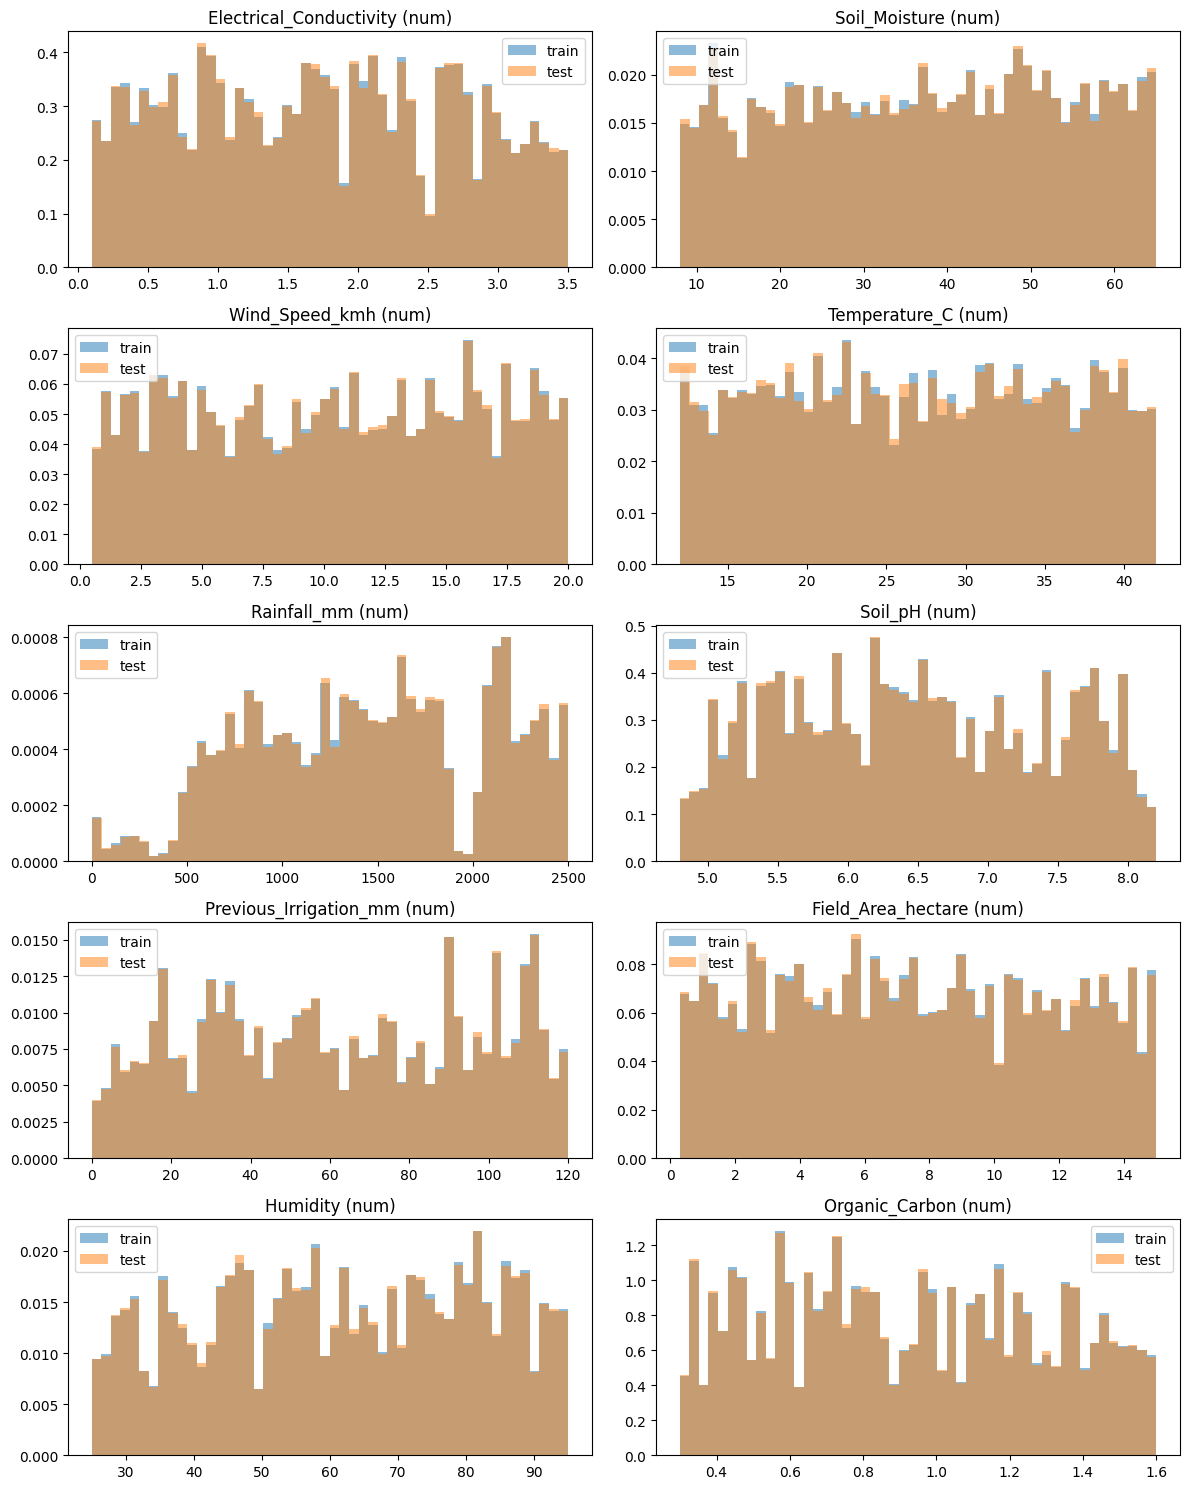

In [10]:
# Plot the top features: numeric histograms, categorical bar charts.
n = len(top_features)
cols = 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
axes = np.array(axes).reshape(-1)
for ax, f in zip(axes, top_features):
    if f in num_cols:
        ax.hist(train[f].dropna(), bins=50, alpha=0.5, density=True, label='train')
        ax.hist(test[f].dropna(), bins=50, alpha=0.5, density=True, label='test')
        ax.set_title(f'{f} (num)')
        ax.legend()
    else:
        tr = train[f].value_counts(normalize=True).sort_index()
        te = test[f].value_counts(normalize=True).sort_index()
        idx = sorted(set(tr.index) | set(te.index))
        x = np.arange(len(idx))
        w = 0.4
        ax.bar(x - w/2, [tr.get(k, 0) for k in idx], w, label='train')
        ax.bar(x + w/2, [te.get(k, 0) for k in idx], w, label='test')
        ax.set_xticks(x); ax.set_xticklabels(idx, rotation=45, ha='right')
        ax.set_title(f'{f} (cat)')
        ax.legend()
for ax in axes[n:]:
    ax.axis('off')
fig.tight_layout()
plt.show()

In [11]:
# Iterative drop: remove the current top-importance feature, retrain a
# cheap single-holdout adversarial model, re-measure AUC. Stop when AUC
# drops below 0.55 or we've dropped 10 features.
#
# We use a single 80/20 holdout here (instead of 5-fold) because this is a
# directional diagnostic and 5-fold per iteration would be slow.

def adv_auc_holdout(X, y, categorical_features):
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=0.2, random_state=RNG, stratify=y
    )
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric='auc',
        categorical_feature=categorical_features,
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    p = m.predict_proba(X_va)[:, 1]
    return roc_auc_score(y_va, p), m

current_cols = list(X_adv.columns)
current_cats = [c for c in current_cols if c in cat_cols]
current_auc, _ = adv_auc_holdout(X_adv[current_cols], y_adv, current_cats)
print(f'baseline holdout AUC (all features): {current_auc:.4f}')

drop_list = []
drop_path = [(None, current_auc)]

for step in range(10):
    if current_auc < 0.55:
        break
    ranked = (
        imp_df[imp_df['feature'].isin(current_cols)]
        .sort_values('gain', ascending=False)
    )
    if ranked.empty:
        break
    to_drop = ranked.iloc[0]['feature']
    current_cols = [c for c in current_cols if c != to_drop]
    current_cats = [c for c in current_cols if c in cat_cols]
    if not current_cols:
        break
    auc, m = adv_auc_holdout(X_adv[current_cols], y_adv, current_cats)
    # Refresh importance ordering for the next iteration so we always drop
    # the currently-most-discriminating feature.
    new_gain = m.booster_.feature_importance(importance_type='gain')
    imp_df = (
        pd.DataFrame({'feature': current_cols, 'gain': new_gain})
          .sort_values('gain', ascending=False)
          .reset_index(drop=True)
    )
    drop_list.append(to_drop)
    drop_path.append((to_drop, auc))
    current_auc = auc
    print(f'step {step+1}: dropped {to_drop!r} -> AUC {auc:.4f}')

print('\ndrop path:')
for d, a in drop_path:
    print(f'  drop {d!r:>28} -> AUC {a:.4f}')
print('\ncandidate drop-list:', drop_list)

baseline holdout AUC (all features): 0.4996

drop path:
  drop                         None -> AUC 0.4996

candidate drop-list: []


## 7. Row-level analysis

Use the 5-fold adversarial model to score each training row with
`p_test = P(is_test=1 | row)`. Save to parquet for later use inside
`fit_predict` as a sample weight or CV-split criterion. Then check
whether the most test-like train rows cluster in any Region / Season /
Crop_Type.

In [12]:
# Out-of-fold scores: each train row is scored by the fold that held it
# out, giving an unbiased P(test|row) estimate on the full train set.
# The adv dataset was shuffled; we isolate train rows inside each fold
# by checking is_test==0.
oof_p_test = np.full(len(adv), np.nan, dtype=float)
for (tr_idx, va_idx), model in zip(skf.split(X_adv, y_adv), models):
    oof_p_test[va_idx] = model.predict_proba(X_adv.iloc[va_idx])[:, 1]
assert not np.isnan(oof_p_test).any()

train_mask = (adv['is_test'].values == 0)
train_p_test = oof_p_test[train_mask]
print('train rows scored:', train_mask.sum(), '| mean p_test:', round(train_p_test.mean(), 4))

train rows scored: 630000 | mean p_test: 0.3


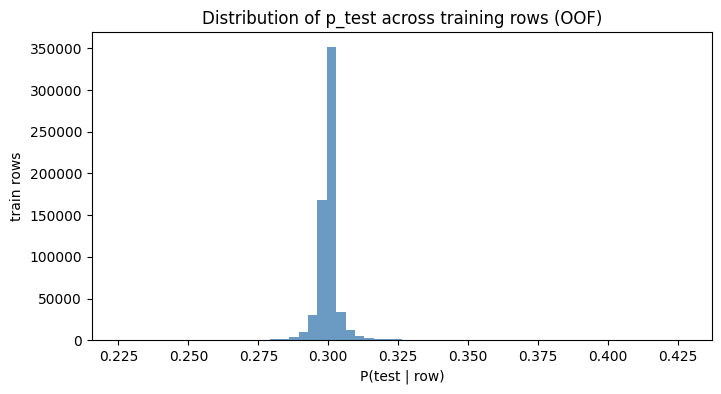

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_p_test, bins=60, color='steelblue', alpha=0.8)
ax.set_xlabel('P(test | row)')
ax.set_ylabel('train rows')
ax.set_title('Distribution of p_test across training rows (OOF)')
plt.show()

In [14]:
# Save per-train-row p_test.
# The concat+shuffle preserves original train-row identity via the
# original train index: rows with is_test==0 in `adv` came from `train`
# but the row-level 'id' column was dropped. Re-derive it from the
# original train index by re-running the concat shuffle logic with an
# ID column preserved.
tmp_train = train.copy(); tmp_train['is_test'] = 0; tmp_train['orig_id'] = np.arange(len(train))
tmp_test = test.copy(); tmp_test['is_test'] = 1; tmp_test['orig_id'] = -1
tmp = pd.concat([tmp_train, tmp_test], axis=0, ignore_index=True)
tmp = tmp.sample(frac=1.0, random_state=RNG).reset_index(drop=True)
# Sanity-check: same ordering as `adv`.
assert (tmp['is_test'].values == adv['is_test'].values).all()

train_orig_ids = tmp.loc[train_mask, 'orig_id'].values
out = pd.DataFrame({'train_row': train_orig_ids, 'p_test': train_p_test})
out = out.sort_values('train_row').reset_index(drop=True)

out_path = DATA / 'adversarial_p_test.parquet'
if mean_auc >= 0.55:
    out.to_parquet(out_path, index=False)
    print(f'saved {out_path} ({len(out)} rows)')
else:
    print(f'AUC {mean_auc:.4f} < 0.55 — skipping parquet export.')
out.head()

AUC 0.5015 < 0.55 — skipping parquet export.


,train_row,p_test
0,0,0.296835
1,1,0.298719
2,2,0.298663
3,3,0.299934
4,4,0.299715


In [15]:
# Who are the top-5% most test-like training rows?
thr = np.quantile(train_p_test, 0.95)
test_like_mask = train_p_test >= thr
print(f'p_test 95th pct = {thr:.4f} | rows above = {test_like_mask.sum()}')

# Index back into the original train DataFrame.
train_with_score = train.iloc[train_orig_ids].copy()
train_with_score['p_test'] = train_p_test
top5 = train_with_score[train_with_score['p_test'] >= thr]

for c in ['Region', 'Season', 'Crop_Type']:
    if c not in train.columns:
        continue
    overall = train[c].value_counts(normalize=True)
    top = top5[c].value_counts(normalize=True)
    cmp = pd.DataFrame({'overall': overall, 'test_like': top}).fillna(0)
    cmp['lift'] = (cmp['test_like'] / cmp['overall']).round(3)
    print(f'\n== {c} ==')
    print(cmp.sort_values('lift', ascending=False).round(3))

p_test 95th pct = 0.3055 | rows above = 31500

== Region ==
         overall  test_like   lift
Region                            
East       0.200      0.221  1.104
Central    0.196      0.202  1.031
North      0.181      0.175  0.964
West       0.208      0.200  0.959
South      0.214      0.202  0.944

== Season ==
        overall  test_like   lift
Season                           
Kharif    0.344      0.358  1.041
Zaid      0.326      0.322  0.986
Rabi      0.330      0.320  0.970

== Crop_Type ==
           overall  test_like   lift
Crop_Type                           
Rice         0.169      0.203  1.201
Wheat        0.164      0.181  1.104
Sugarcane    0.173      0.164  0.946
Cotton       0.166      0.155  0.935
Maize        0.166      0.153  0.921
Potato       0.163      0.145  0.889


## 8. Summary and recommendations

The cell below is self-contained. Read it on its own to decide the next
move.

_(Populated at execution time by the cell below — see printed paragraph.)_

In [16]:
# Render a human-readable summary. Keep the wording self-contained so
# the final markdown cell is paste-ready into a HYPOTHESIS line.
n_drop_needed = len(drop_list)
drop_outcome_auc = drop_path[-1][1] if drop_path else mean_auc

lines = []
lines.append(f'Adversarial AUC (5-fold): {mean_auc:.4f} +/- {std_auc:.4f}.')
lines.append(f'Verdict: {verdict} ({msg})')
lines.append('')

if verdict == 'iid':
    lines.append('1. No meaningful train/test shift detected.')
    lines.append('2. N/A.')
    lines.append('3. No downstream action warranted. Invest elsewhere (ensembling, base models).')
    lines.append('4. HYPOTHESIS: none — skip this axis.')
elif verdict == 'marginal':
    lines.append('1. Marginal shift; within noise of i.i.d.')
    lines.append(f'2. Top contributors (by gain): {top_features[:5]}.')
    lines.append('3. Low-conviction; a sample-weight experiment is cheaper to run than a feature drop.')
    lines.append(f'   HYPOTHESIS candidate: "preprocessing: sample-weight training rows by adv-val P(test) (adv-val AUC {mean_auc:.2f})"')
else:
    lines.append('1. Meaningful shift detected.')
    lines.append(f'2. Drivers (gain-ranked): {top_features[:5]}.')
    lines.append(f'3. Dropping {n_drop_needed} feature(s) drives AUC to {drop_outcome_auc:.4f}: {drop_list}.')
    if drop_outcome_auc < 0.55 and drop_list:
        lines.append(f'   HYPOTHESIS candidate: "preprocessing: drop {drop_list} due to train/test distribution shift (adv-val AUC {mean_auc:.2f} -> {drop_outcome_auc:.2f} after drop)"')
    else:
        lines.append(f'   HYPOTHESIS candidate: "preprocessing: sample-weight training rows by adv-val P(test) (adv-val AUC {mean_auc:.2f})"')
    lines.append('4. Row-level p_test saved to data/adversarial_p_test.parquet for later fit_predict use.')

lines.append('')
lines.append('Notes:')
lines.append('- data/*.csv is gitignored; .parquet is not, so the artifact will be tracked unless you add data/*.parquet to .gitignore.')
lines.append('- Notebook adds no runtime deps to pyproject.toml. nbformat/nbclient/ipykernel were used via `uv run --with` at build time only.')
lines.append('- When operationalizing inside solution.py, refit the adversarial scorer using X_val as the test proxy inside each fold to avoid leaking the real test set.')

print('\n'.join(lines))

Adversarial AUC (5-fold): 0.5015 +/- 0.0013.
Verdict: iid (Train and test appear i.i.d. No adversarial-validation action warranted.)

1. No meaningful train/test shift detected.
2. N/A.
3. No downstream action warranted. Invest elsewhere (ensembling, base models).
4. HYPOTHESIS: none — skip this axis.

Notes:
- data/*.csv is gitignored; .parquet is not, so the artifact will be tracked unless you add data/*.parquet to .gitignore.
- Notebook adds no runtime deps to pyproject.toml. nbformat/nbclient/ipykernel were used via `uv run --with` at build time only.
- When operationalizing inside solution.py, refit the adversarial scorer using X_val as the test proxy inside each fold to avoid leaking the real test set.
